In [1]:
import numpy as np # Linear Algebra
import matplotlib.pyplot as plt # Plotting
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting

In [2]:
def RotX(theta):
    ct = np.cos(theta)
    st = np.sin(theta)
    R = np.eye(3, 3)
    R[1, 1] = ct
    R[1, 2] = -st
    R[2, 1] = st
    R[2, 2] = ct
    return R

def RotY(theta):
    ct = np.cos(theta)
    st = np.sin(theta)
    R = np.eye(3, 3)
    R[0, 0] = ct
    R[0, 2] = st
    R[2, 0] = -st
    R[2, 2] = ct
    return R

def RotZ(theta):
    ct = np.cos(theta)
    st = np.sin(theta)
    R = np.eye(3, 3)
    R[0, 0] = ct
    R[0, 1] = -st
    R[1, 0] = st
    R[1, 1] = ct
    return R

In [3]:
def transform_point(pb, R, p = np.zeros((3, 1))):
    return p + R @ pb

def transform_vector(vb, R):
    return R @ vb

def homogeneous(R, p = np.zeros((3, 1))):
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3:] = p

    return T

In [4]:
pb = np.array([[0.1, 0.2, -0.1]]).T

R = RotX(np.pi / 2.)
pc = np.array([[2., 0., 0.]]).T

T = homogeneous(R, pc)

pbh = np.vstack([pb, 1.])
vbh = np.vstack([pb, 0.])

pw1 = transform_point(pb, R, pc)
pw2 = T @ pbh

print(pw1.T)
print(pw2.T)

vw1 = transform_vector(pb, R)
vw2 = T @ vbh

print(vw1.T)
print(vw2.T)

[[2.1 0.1 0.2]]
[[2.1 0.1 0.2 1. ]]
[[0.1 0.1 0.2]]
[[0.1 0.1 0.2 0. ]]


In [5]:
def rot_inv(R):
    return R.T

def hom_inv(T):
    R = T[:3, :3]
    t = T[:3, 3:]

    Tn = np.eye(4)
    Tn[:3, :3] = R.T
    Tn[:3, 3:] = -R.T @ t

    return Tn

In [6]:
R = RotY(np.pi / 4.)
pc = np.array([[0.5, 0., 0.]]).T

T = homogeneous(R, pc)

print(rot_inv(R))
print(hom_inv(T)[:3, :3])

print(np.linalg.inv(R))

print(hom_inv(T))
print(np.linalg.inv(T))

[[ 0.70710678  0.         -0.70710678]
 [ 0.          1.          0.        ]
 [ 0.70710678  0.          0.70710678]]
[[ 0.70710678  0.         -0.70710678]
 [ 0.          1.          0.        ]
 [ 0.70710678  0.          0.70710678]]
[[ 0.70710678  0.         -0.70710678]
 [ 0.          1.          0.        ]
 [ 0.70710678  0.          0.70710678]]
[[ 0.70710678  0.         -0.70710678 -0.35355339]
 [ 0.          1.          0.          0.        ]
 [ 0.70710678  0.          0.70710678 -0.35355339]
 [ 0.          0.          0.          1.        ]]
[[ 0.70710678  0.         -0.70710678 -0.35355339]
 [ 0.          1.          0.          0.        ]
 [ 0.70710678  0.          0.70710678 -0.35355339]
 [ 0.          0.          0.          1.        ]]


In [7]:
def transform_point_homogeneous(T, pb):
    return (T @ np.vstack([pb, 1.]))[:3, :]

def transform_vector_homogeneous(T, vb):
    return (T @ np.vstack([vb, 0.]))[:3, :]

pb = np.array([[0.5, 0.2, -0.1]]).T

pw = transform_point_homogeneous(T, pb)

pbn = transform_point_homogeneous(hom_inv(T), pw)

print(pb.T)
print(pbn.T)
print(pw.T)

[[ 0.5  0.2 -0.1]]
[[ 0.5  0.2 -0.1]]
[[ 0.78284271  0.2        -0.42426407]]


In [8]:
pb = np.array([[0.5, 0.2, -0.1]]).T

pw = R @ pb
pbn = rot_inv(R) @ pw

print(pb.T)
print(pbn.T)
print(pw.T)

[[ 0.5  0.2 -0.1]]
[[ 0.5  0.2 -0.1]]
[[ 0.28284271  0.2        -0.42426407]]


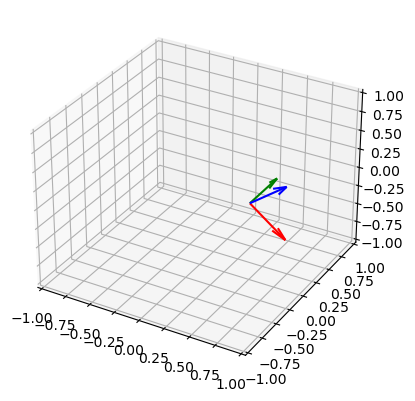

In [16]:
# Plot the original and transformed trajectories
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

def plot_frame(ax, T):
    origin = T[:3, 3:]
    R = T[:3, :3]
    xaxis = R @ np.array([[1., 0., 0.]]).T
    yaxis = R @ np.array([[0., 1., 0.]]).T
    zaxis = R @ np.array([[0., 0., 1.]]).T

    ax.quiver(*origin, *xaxis, color='r', length=0.5)
    ax.quiver(*origin, *yaxis, color='g', length=0.5)
    ax.quiver(*origin, *zaxis, color='b', length=0.5)

def plot_frame2(ax, T):
    origin = T[:3, 3]
    x_axis = T[:3, 0]
    y_axis = T[:3, 1]
    z_axis = T[:3, 2]

    x_axis = x_axis / np.linalg.norm(x_axis)
    y_axis = y_axis / np.linalg.norm(y_axis)
    z_axis = z_axis / np.linalg.norm(z_axis)

    ax.quiver(*origin, *x_axis, color='r', length=0.5, normalize=True)
    ax.quiver(*origin, *y_axis, color='g', length=0.5, normalize=True)
    ax.quiver(*origin, *z_axis, color='b', length=0.5, normalize=True)

plot_frame(ax, T)
plot_frame2(ax, T)

ax.set_xlim([-1., 1.])
ax.set_ylim([-1., 1.])
ax.set_zlim([-1., 1.])

plt.show()

In [ ]:
# Let's create some coordinate frames
Tbody = homogeneous(RotZ(np.pi / 2.), np.array([[0.5, 0.5, 0.]]).T)

# Let's plot a few things
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

plot_frame(ax, np.eye(4)) # world frame
plot_frame(ax, Tbody) # our body frame

# point in body
pb = np.array([[0.2, -0.2, 0.]]).T

ax.scatter(pb[0, 0], pb[1, 0], pb[2, 0], c='r') # plot in world frame (this is wrong)
pw = transform_point_homogeneous(Tbody, pb)
ax.scatter(pw[0, 0], pw[1, 0], pw[2, 0], c='b')

ax.set_xlim([-1., 1.])
ax.set_ylim([-1., 1.])
ax.set_zlim([-1., 1.])

plt.show()